## Importing Libraries

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from imblearn.under_sampling import RandomUnderSampler
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import torch
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import warnings
from sklearn.metrics import classification_report
import pickle
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("C:/Users/user/Downloads/complaints_processed.csv/complaints_processed.csv")
df.head(10)

,Unnamed: 0,product,narrative
0,0,credit_card,purchase order day shipping amount receive pro...
1,1,credit_card,forwarded message date tue subject please inve...
2,2,retail_banking,forwarded message cc sent friday pdt subject f...
3,3,credit_reporting,payment history missing credit report speciali...
4,4,credit_reporting,payment history missing credit report made mis...
5,5,credit_reporting,payment history missing credit report made mis...
6,6,credit_reporting,va date complaint experian credit bureau invol...
7,7,credit_reporting,account reported abbreviated name full name se...
8,8,credit_reporting,account reported abbreviated name full name se...
9,9,credit_reporting,usdoexxxx account reported abbreviated name fu...


In [3]:
df.tail(10)

,Unnamed: 0,product,narrative
162411,162411,retail_banking,zelle suspended account without cause banking ...
162412,162412,debt_collection,zero contact made debt supposedly resolved fou...
162413,162413,mortgages_and_loans,zillow home loan nmls nmls actual quote provid...
162414,162414,debt_collection,zuntafi sent notice willing settle defaulted s...
162415,162415,debt_collection,name
162416,162416,debt_collection,name
162417,162417,credit_card,name
162418,162418,debt_collection,name
162419,162419,credit_card,name
162420,162420,credit_reporting,name


## Data Cleaning

In [4]:
print(f'Size of dataframe: {df.shape}')
print(f'Datatype of columns:\n {df.dtypes}')
print(f'product category count:\n {df['product'].value_counts()}')
print(f'Number of Null values in dataframe:\n {df.isnull().sum()}')

Size of dataframe: (162421, 3)
Datatype of columns:
 Unnamed: 0     int64
product       object
narrative     object
dtype: object
product category count:
 product
credit_reporting       91179
debt_collection        23150
mortgages_and_loans    18990
credit_card            15566
retail_banking         13536
Name: count, dtype: int64
Number of Null values in dataframe:
 Unnamed: 0     0
product        0
narrative     10
dtype: int64


In [5]:
df = df.drop_duplicates()
df = df.drop(['Unnamed: 0'], axis=1)
df = df[df['narrative'] != 'name']
df = df.dropna()
df.isnull().sum()

product      0
narrative    0
dtype: int64

In [6]:
df.tail()

,product,narrative
162410,credit_reporting,zales comenity bank closed sold account report...
162411,retail_banking,zelle suspended account without cause banking ...
162412,debt_collection,zero contact made debt supposedly resolved fou...
162413,mortgages_and_loans,zillow home loan nmls nmls actual quote provid...
162414,debt_collection,zuntafi sent notice willing settle defaulted s...


## Data Visualization 

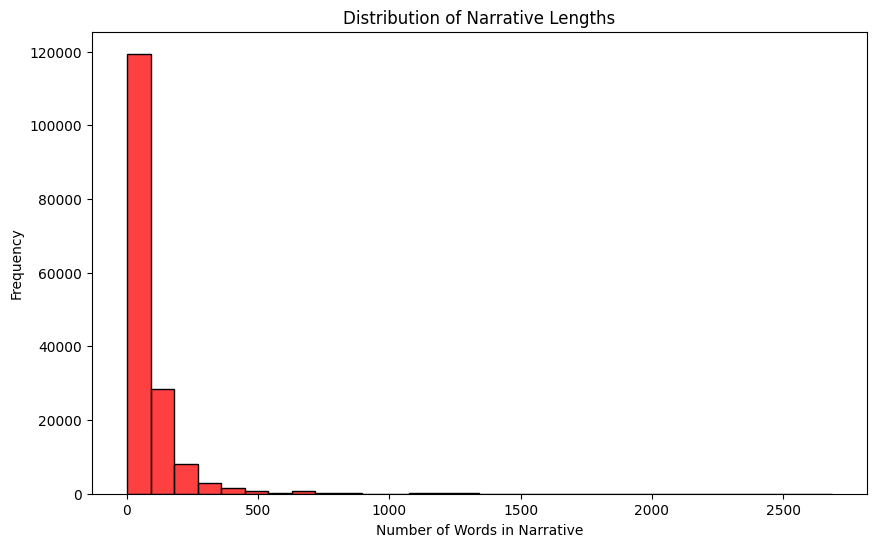

In [7]:
df['narrative_length'] = df['narrative'].apply(lambda x: len(x.split()))
plt.figure(figsize = (10, 6))
sns.histplot(df['narrative_length'], bins = 30, color = 'red')
plt.title('Distribution of Narrative Lengths')
plt.xlabel('Number of Words in Narrative')
plt.ylabel('Frequency')
plt.show()

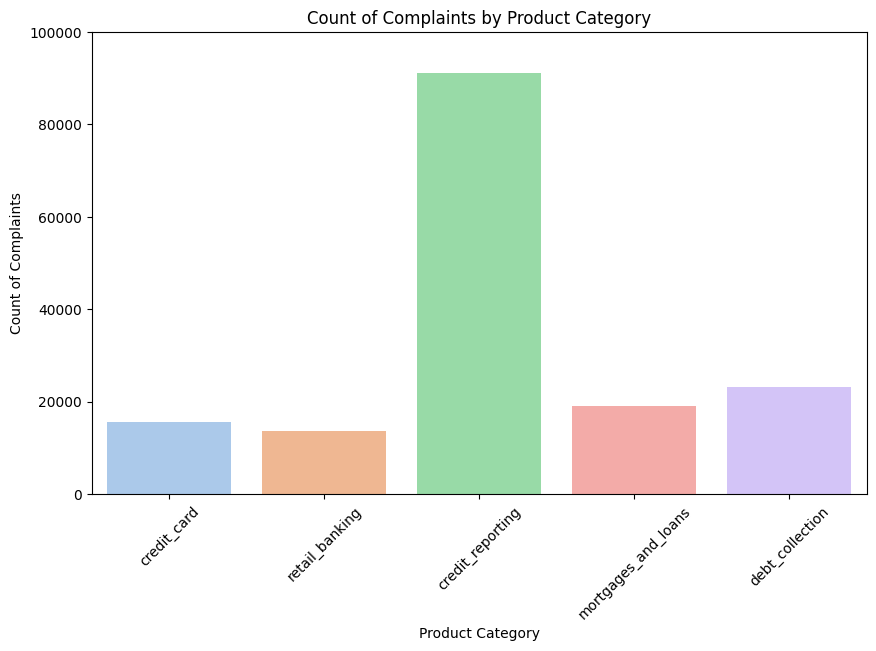

In [8]:
plt.figure(figsize = (10, 6))
sns.countplot(x = 'product', data = df, palette = 'pastel')
plt.title('Count of Complaints by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Count of Complaints')
plt.xticks(rotation = 45)
plt.ylim(0, 100000)
plt.show()

Dataset is imbalanced. Sampling can improve training 

In [9]:
from sklearn.model_selection import train_test_split
df = df.drop(['narrative_length'], axis=1)
train_data, test_data = train_test_split(df, test_size = 0.20)
train_data.shape, test_data.shape

((129924, 2), (32481, 2))

In [10]:
train_data

,product,narrative
36336,retail_banking,called binance support needed withdraw fund le...
99668,credit_reporting,identity used someone else open fraudulent acc...
101018,credit_reporting,name ohio dob s would like order full complete...
76943,credit_reporting,sent transunion dispute letter day ago yet res...
46650,retail_banking,claim opened today unauthorized transaction on...
...,...,...
140101,credit_reporting,first time encountered identity theft pulled c...
96047,credit_reporting,midland credit management agreed remove accoun...
61624,credit_reporting,submitted dispute proof uploaded three credit ...
143245,credit_reporting,equifax escalation department contacted follow...


### Undersampling

In [11]:
min_value = train_data['product'].value_counts().min()
df1 = np.random.choice(train_data[train_data['product']=='credit_card'].index,size = min_value, replace=False)
df2 = np.random.choice(train_data[train_data['product']=='debt_collection'].index,size = min_value, replace=False)
df3 = np.random.choice(train_data[train_data['product']=='mortgages_and_loans'].index,size = min_value, replace=False)
df4 = np.random.choice(train_data[train_data['product']=='retail_banking'].index,size=min_value,replace=False)
df5 = np.random.choice(train_data[train_data['product']=='credit_reporting'].index,size=min_value,replace=False)
concat_df = np.concatenate((df1, df2, df3, df4, df5))



In [12]:
df_replicate = train_data[train_data.index.isin(concat_df)]
df_replicate

,product,narrative
36336,retail_banking,called binance support needed withdraw fund le...
46650,retail_banking,claim opened today unauthorized transaction on...
125383,debt_collection,sometime account fraudulently opened name cont...
8315,credit_reporting,auto insurer using lexisnexis review public in...
133377,mortgages_and_loans,much say please see attached document thank he...
...,...,...
97046,retail_banking,bank charged fee balance asked waive courtesy ...
8738,credit_reporting,bank america allowed covid delay payment repor...
113919,mortgages_and_loans,requested payoff statement phh mortgage receiv...
12795,debt_collection,compliant duplicate please refer previous comp...


In [13]:
train_data = df_replicate
train_data['product'].value_counts()

product
retail_banking         10827
debt_collection        10827
credit_reporting       10827
mortgages_and_loans    10827
credit_card            10827
Name: count, dtype: int64

## Data Preprocessing

In [14]:
nltk.download('stopwords')
nltk.download('wordnet')
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [15]:
def preprocess_text(df):
    df['narrative'] = df['narrative'].str.lower()
    df['narrative'] = df['narrative'].apply(lambda x: re.sub(r'[^\w\s]', '', x))
    df['narrative'] = df['narrative'].apply(lambda x: x.split())
    df['narrative'] = df['narrative'].apply(lambda x: [lemmatizer.lemmatize(word) for word in x if word not in stop_words])
    return df

train_data = preprocess_text(train_data)
test_data = preprocess_text(test_data)
train_data.head()

,product,narrative
36336,retail_banking,"[called, binance, support, needed, withdraw, f..."
46650,retail_banking,"[claim, opened, today, unauthorized, transacti..."
125383,debt_collection,"[sometime, account, fraudulently, opened, name..."
8315,credit_reporting,"[auto, insurer, using, lexisnexis, review, pub..."
133377,mortgages_and_loans,"[much, say, please, see, attached, document, t..."


## Tokenizing Sentences and Fixing Sentence Length

In [ ]:
max_words = 5000
max_sequence_length = 170
embedding_dim = 128

from collections import Counter
all_tokens = [token for sentence in train_data.narrative for token in sentence]
counter = Counter(all_tokens)
most_common = counter.most_common(max_words - 2)  # reserve 2 for <pad> and <unk>

vocab = {'<pad>': 0, '<unk>': 1} # Build vocab: word -> index
for i, (word, _) in enumerate(most_common, start=2):
    vocab[word] = i

inv_vocab = {i: w for w, i in vocab.items()} # Reverse vocab for debugging (optional)

# Encoding function: tokens -> indices
def encode(tokens):
    indices = []
    for t in tokens:
        idx = vocab.get(t, vocab['<unk>'])
        if idx < 0 or idx >= len(vocab):
            idx = vocab['<unk>']
        indices.append(idx)
    return torch.tensor(indices, dtype=torch.long)


train_sequences = [encode(tokens) for tokens in train_data.narrative]
test_sequences  = [encode(tokens) for tokens in test_data.narrative]


#  Padding sequences to fixed length (max_sequence_length) with <pad> token
def pad_fixed(seq, max_len=max_sequence_length):
    seq = seq[:max_len]  # truncate if too long
    padding_len = max_len - len(seq)
    if padding_len > 0:
        padding = torch.full((padding_len,), vocab['<pad>'], dtype=torch.long)
        seq = torch.cat([seq, padding])
    return seq

train_padded = torch.stack([pad_fixed(seq) for seq in train_sequences])
test_padded  = torch.stack([pad_fixed(seq) for seq in test_sequences])

print("Train shape:", train_padded.shape)  # (num_samples, max_sequence_length)
print("Test shape:", test_padded.shape)

Train shape: torch.Size([54135, 170])
Test shape: torch.Size([32481, 170])


In [17]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [18]:
le = LabelEncoder()
train_data['product'] = le.fit_transform(train_data['product'])
test_data['product'] = le.transform(test_data['product'])
train_labels = torch.tensor(train_data['product'].values, dtype=torch.long)
test_labels = torch.tensor(test_data['product'].values, dtype=torch.long)

In [ ]:
class LSTMClassifier(nn.Module):
    def __init__(self, embedding_dim, hidden_dim, vocab_size, output_dim, num_layers=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=vocab['<pad>'])
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers=num_layers, batch_first=True, bidirectional = True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        embedded = self.embedding(x)  
        _, (hidden, _) = self.lstm(embedded)
        logits = self.fc(hidden[-1]) 
        return logits

hidden_dim = 64
num_classes = len(le.classes_) 
model = LSTMClassifier(embedding_dim, hidden_dim, len(vocab), num_classes)
model.to(device)

LSTMClassifier(
  (embedding): Embedding(5000, 128, padding_idx=0)
  (lstm): LSTM(128, 64, num_layers=2, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=64, out_features=5, bias=True)
)

In [20]:
train_dataset = TensorDataset(train_padded, train_labels)
test_dataset = TensorDataset(test_padded, test_labels)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

In [21]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item() 
    acc = (correct / len(y_pred)) * 100
    return acc

In [22]:
epochs = 4

for epoch in range(epochs):
    total_train_loss = 0
    total_train_acc = 0

    model.train()
    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        y_logits = model(x_batch)
        loss = loss_fn(y_logits, y_batch)
        y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()
        total_train_acc += accuracy_fn(y_batch, y_pred)

    total_test_loss = 0
    total_test_acc = 0

    model.eval()
    with torch.inference_mode():
      for x_test_batch, y_test_batch in test_loader:
        x_test_batch, y_test_batch = x_test_batch.to(device), y_test_batch.to(device)     
        y_logits = model(x_test_batch)
        y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)
        test_loss = loss_fn(y_logits, y_test_batch)
        total_test_loss += test_loss
        total_test_acc += accuracy_fn(y_test_batch, y_pred)

    avg_train_loss = total_train_loss / len(train_loader)
    avg_train_acc = total_train_acc / len(train_loader)
    avg_test_loss = total_test_loss / len(test_loader)
    avg_test_acc = total_test_acc / len(test_loader)


    print(f"Epoch: {epoch} | Loss: {avg_train_loss:.3f}, Avg Train Acc: {avg_train_acc:.2f}% | Avg Test Loss: {avg_test_loss:.3f}, Avg Test Acc: {avg_test_acc:.2f}%")

Epoch: 0 | Loss: 0.683, Avg Train Acc: 76.59% | Avg Test Loss: 0.599, Avg Test Acc: 79.53%
Epoch: 1 | Loss: 0.490, Avg Train Acc: 83.72% | Avg Test Loss: 0.520, Avg Test Acc: 82.38%
Epoch: 2 | Loss: 0.415, Avg Train Acc: 86.31% | Avg Test Loss: 0.469, Avg Test Acc: 83.51%
Epoch: 3 | Loss: 0.365, Avg Train Acc: 87.82% | Avg Test Loss: 0.472, Avg Test Acc: 83.35%


In [24]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=le.classes_))

                     precision    recall  f1-score   support

        credit_card       0.68      0.84      0.75      3170
   credit_reporting       0.96      0.82      0.88     18044
    debt_collection       0.68      0.83      0.75      4716
mortgages_and_loans       0.74      0.88      0.81      3843
     retail_banking       0.83      0.86      0.85      2708

           accuracy                           0.83     32481
          macro avg       0.78      0.85      0.81     32481
       weighted avg       0.85      0.83      0.84     32481



In [28]:
torch.save(model.state_dict(), 'complaint_classifier.pt')

with open('vocab.pkl', 'wb') as f:
    pickle.dump(vocab, f)

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)